# Solar Flux Prediction

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux (it runs in the global terminal).")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp/tmux-1022/default,126489,1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
print("--- Daily Loading and Aggregation ---")
df = pd.read_csv("../Data/MARSIS_historical_dataset.csv", sep=";")
df.columns = df.columns.str.strip()

# TIME CONVERSION
df['datetime'] = pd.to_datetime(df['FM_data_ephemeris_time'], unit='s', origin=pd.Timestamp('2000-01-01 12:00:00'))

# daily aggregation
df_daily = df.groupby(df['datetime'].dt.to_period('D')).agg({
    'FM_data_F10_7_index': 'mean'
}).reset_index()

df_daily['datetime'] = df_daily['datetime'].dt.to_timestamp()

# Filling in missing days before extracting temporal features
df_daily = df_daily.set_index('datetime').asfreq('D', method='ffill').reset_index()

# Temporal feature extraction (now based on a perfect calendar with no gaps)
df_daily['day_of_year'] = df_daily['datetime'].dt.dayofyear
df_daily['day_sin'] = np.sin(2 * np.pi * df_daily['day_of_year'] / 365.25)
df_daily['day_cos'] = np.cos(2 * np.pi * df_daily['day_of_year'] / 365.25)

print(f"Daily dataset created. Total days available: {len(df_daily)}")

--- Daily Loading and Aggregation ---
Daily dataset created. Total days available: 5532


In [5]:
import numpy as np
from time_series_utils import *

LOOKBACK_WINDOW = 30 

# creating the matrices using the daily dataset and the day of the year
X_flux, X_time, y = create_dataset_windows(
    data=df_daily, 
    target_col='FM_data_F10_7_index', 
    time_col=['day_sin', 'day_cos'],  
    lookback=LOOKBACK_WINDOW
)

# Split Cronologico (80% Train, 20% Test)
split_idx = int(len(y) * 0.8)

X_flux_train, X_flux_test = X_flux[:split_idx], X_flux[split_idx:]
X_time_train, X_time_test = X_time[:split_idx], X_time[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

## Linear regression for solar flux prediction 

In [6]:
print("\n--- Training: Linear regression ---")

scaler = StandardScaler()
X_flux_train_scaled = scaler.fit_transform(X_flux_train.reshape(-1, 1)).reshape(X_flux_train.shape)
X_flux_test_scaled = scaler.transform(X_flux_test.reshape(-1, 1)).reshape(X_flux_test.shape)

# combining the features
X_time_train_flat = X_time_train.reshape(X_time_train.shape[0], -1)
X_time_test_flat = X_time_test.reshape(X_time_test.shape[0], -1)

# combining the flux and the flattened temporal coordinates
X_linear_train = np.hstack((X_flux_train_scaled, X_time_train_flat))
X_linear_test = np.hstack((X_flux_test_scaled, X_time_test_flat))

# initialization and fit
lr_model = LinearRegression()
lr_model.fit(X_linear_train, y_train)

# prediction and evaluation
y_pred_lr = lr_model.predict(X_linear_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"[Linear Regression] Test MAE: {mae_lr:.3f}, Test RMSE: {rmse_lr:.3f}")


--- Training: Linear regression ---
[Linear Regression] Test MAE: 0.411, Test RMSE: 1.382


## LSTM for solar flux prediction

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("\n--- Training: PyTorch LSTM (Daily Data) ---")

X_flux_train_3d = np.expand_dims(X_flux_train_scaled, axis=-1)
X_flux_test_3d = np.expand_dims(X_flux_test_scaled, axis=-1)

y_train_2d = y_train.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_2d)
y_test_scaled = scaler_y.transform(y_test_2d)

X_lstm_train = np.concatenate((X_flux_train_3d, X_time_train), axis=-1)
X_lstm_test = np.concatenate((X_flux_test_3d, X_time_test), axis=-1)


--- Training: PyTorch LSTM (Daily Data) ---


### 100 epochs

In [8]:
from utils.train_pytorch_model import *
from models.LSTM import *

trained_lstm, device, training_history = train_pytorch_model(
    X_train=X_lstm_train,         
    y_train=y_train_scaled,       
    input_dim=3,                  
    model_class=LSTMRegressor,    
    epochs=100,                   
    patience=8,                   
    batch_size=32,                
    hidden_dim=32                
)

# =====================================================================
# inference
# =====================================================================
trained_lstm.eval()
X_test_t = torch.tensor(X_lstm_test, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_lstm_scaled = trained_lstm(X_test_t).cpu().numpy()

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f"\n[LSTM Network] Test MAE: {mae_lstm:.3f}, Test RMSE: {rmse_lstm:.3f}")

Early stopping at epoch 47

[LSTM Network] Test MAE: 0.501, Test RMSE: 1.306



Plots successfully saved to:
- plots/training_history_20260728_113842.png
- plots/training_history_20260728_113842.pdf


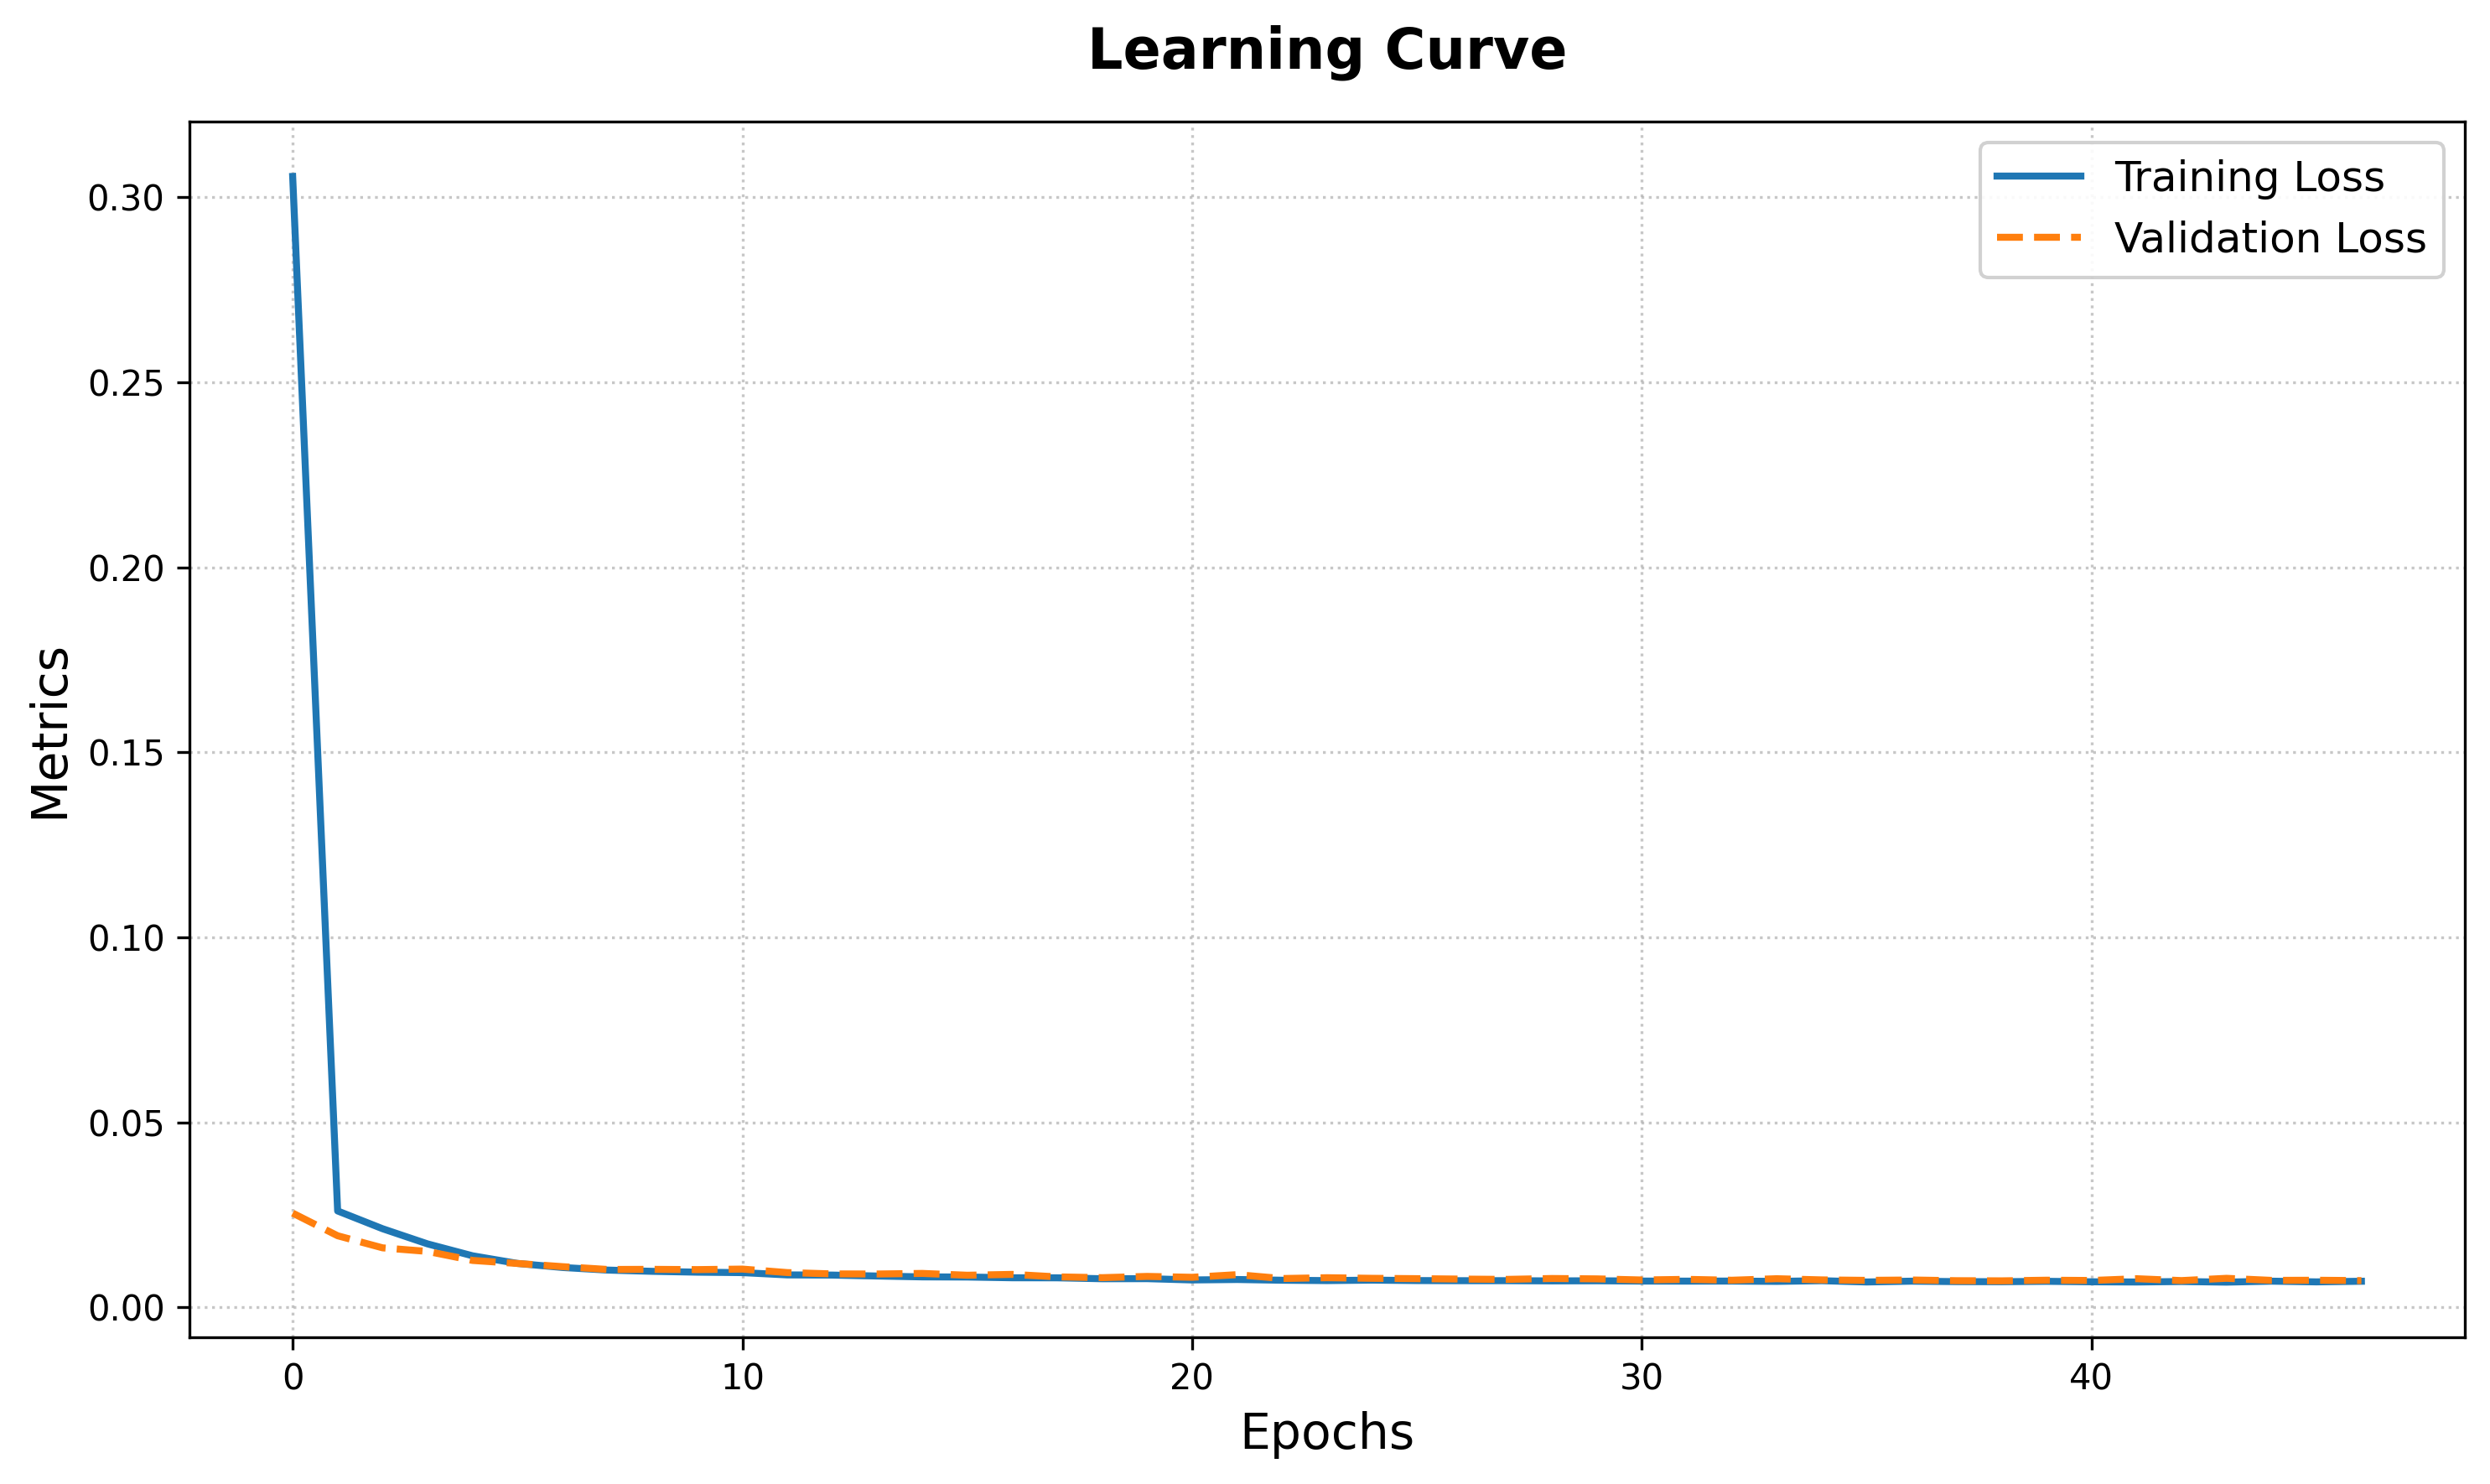

In [9]:
plot_and_save_history(training_history, save_dir="plots")

### 1000 epochs

In [10]:
from utils.train_pytorch_model import *
from models.LSTM import *

trained_lstm_2, device_2, training_history_2 = train_pytorch_model(
    X_train=X_lstm_train,         
    y_train=y_train_scaled,       
    input_dim=3,                  
    model_class=LSTMRegressor,    
    epochs=1000,                   
    patience=8,                   
    batch_size=64,                
    hidden_dim=256                
)

# =====================================================================
# Inference
# =====================================================================
trained_lstm_2.eval()
X_test_t_2 = torch.tensor(X_lstm_test, dtype=torch.float32).to(device_2)

with torch.no_grad():
    y_pred_lstm_2_scaled = trained_lstm_2(X_test_t_2).cpu().numpy()

y_pred_lstm_2 = scaler_y.inverse_transform(y_pred_lstm_2_scaled).flatten()


from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm_2 = mean_absolute_error(y_test, y_pred_lstm_2)
rmse_lstm_2 = np.sqrt(mean_squared_error(y_test, y_pred_lstm_2))

print(f"\n[LSTM Network] Test MAE: {mae_lstm_2:.3f}, Test RMSE: {rmse_lstm_2:.3f}")

Training:   0%|                                                                                                                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 37

[LSTM Network] Test MAE: 0.647, Test RMSE: 1.380



Plots successfully saved to:
- plots/training_history_20260728_113906.png
- plots/training_history_20260728_113906.pdf


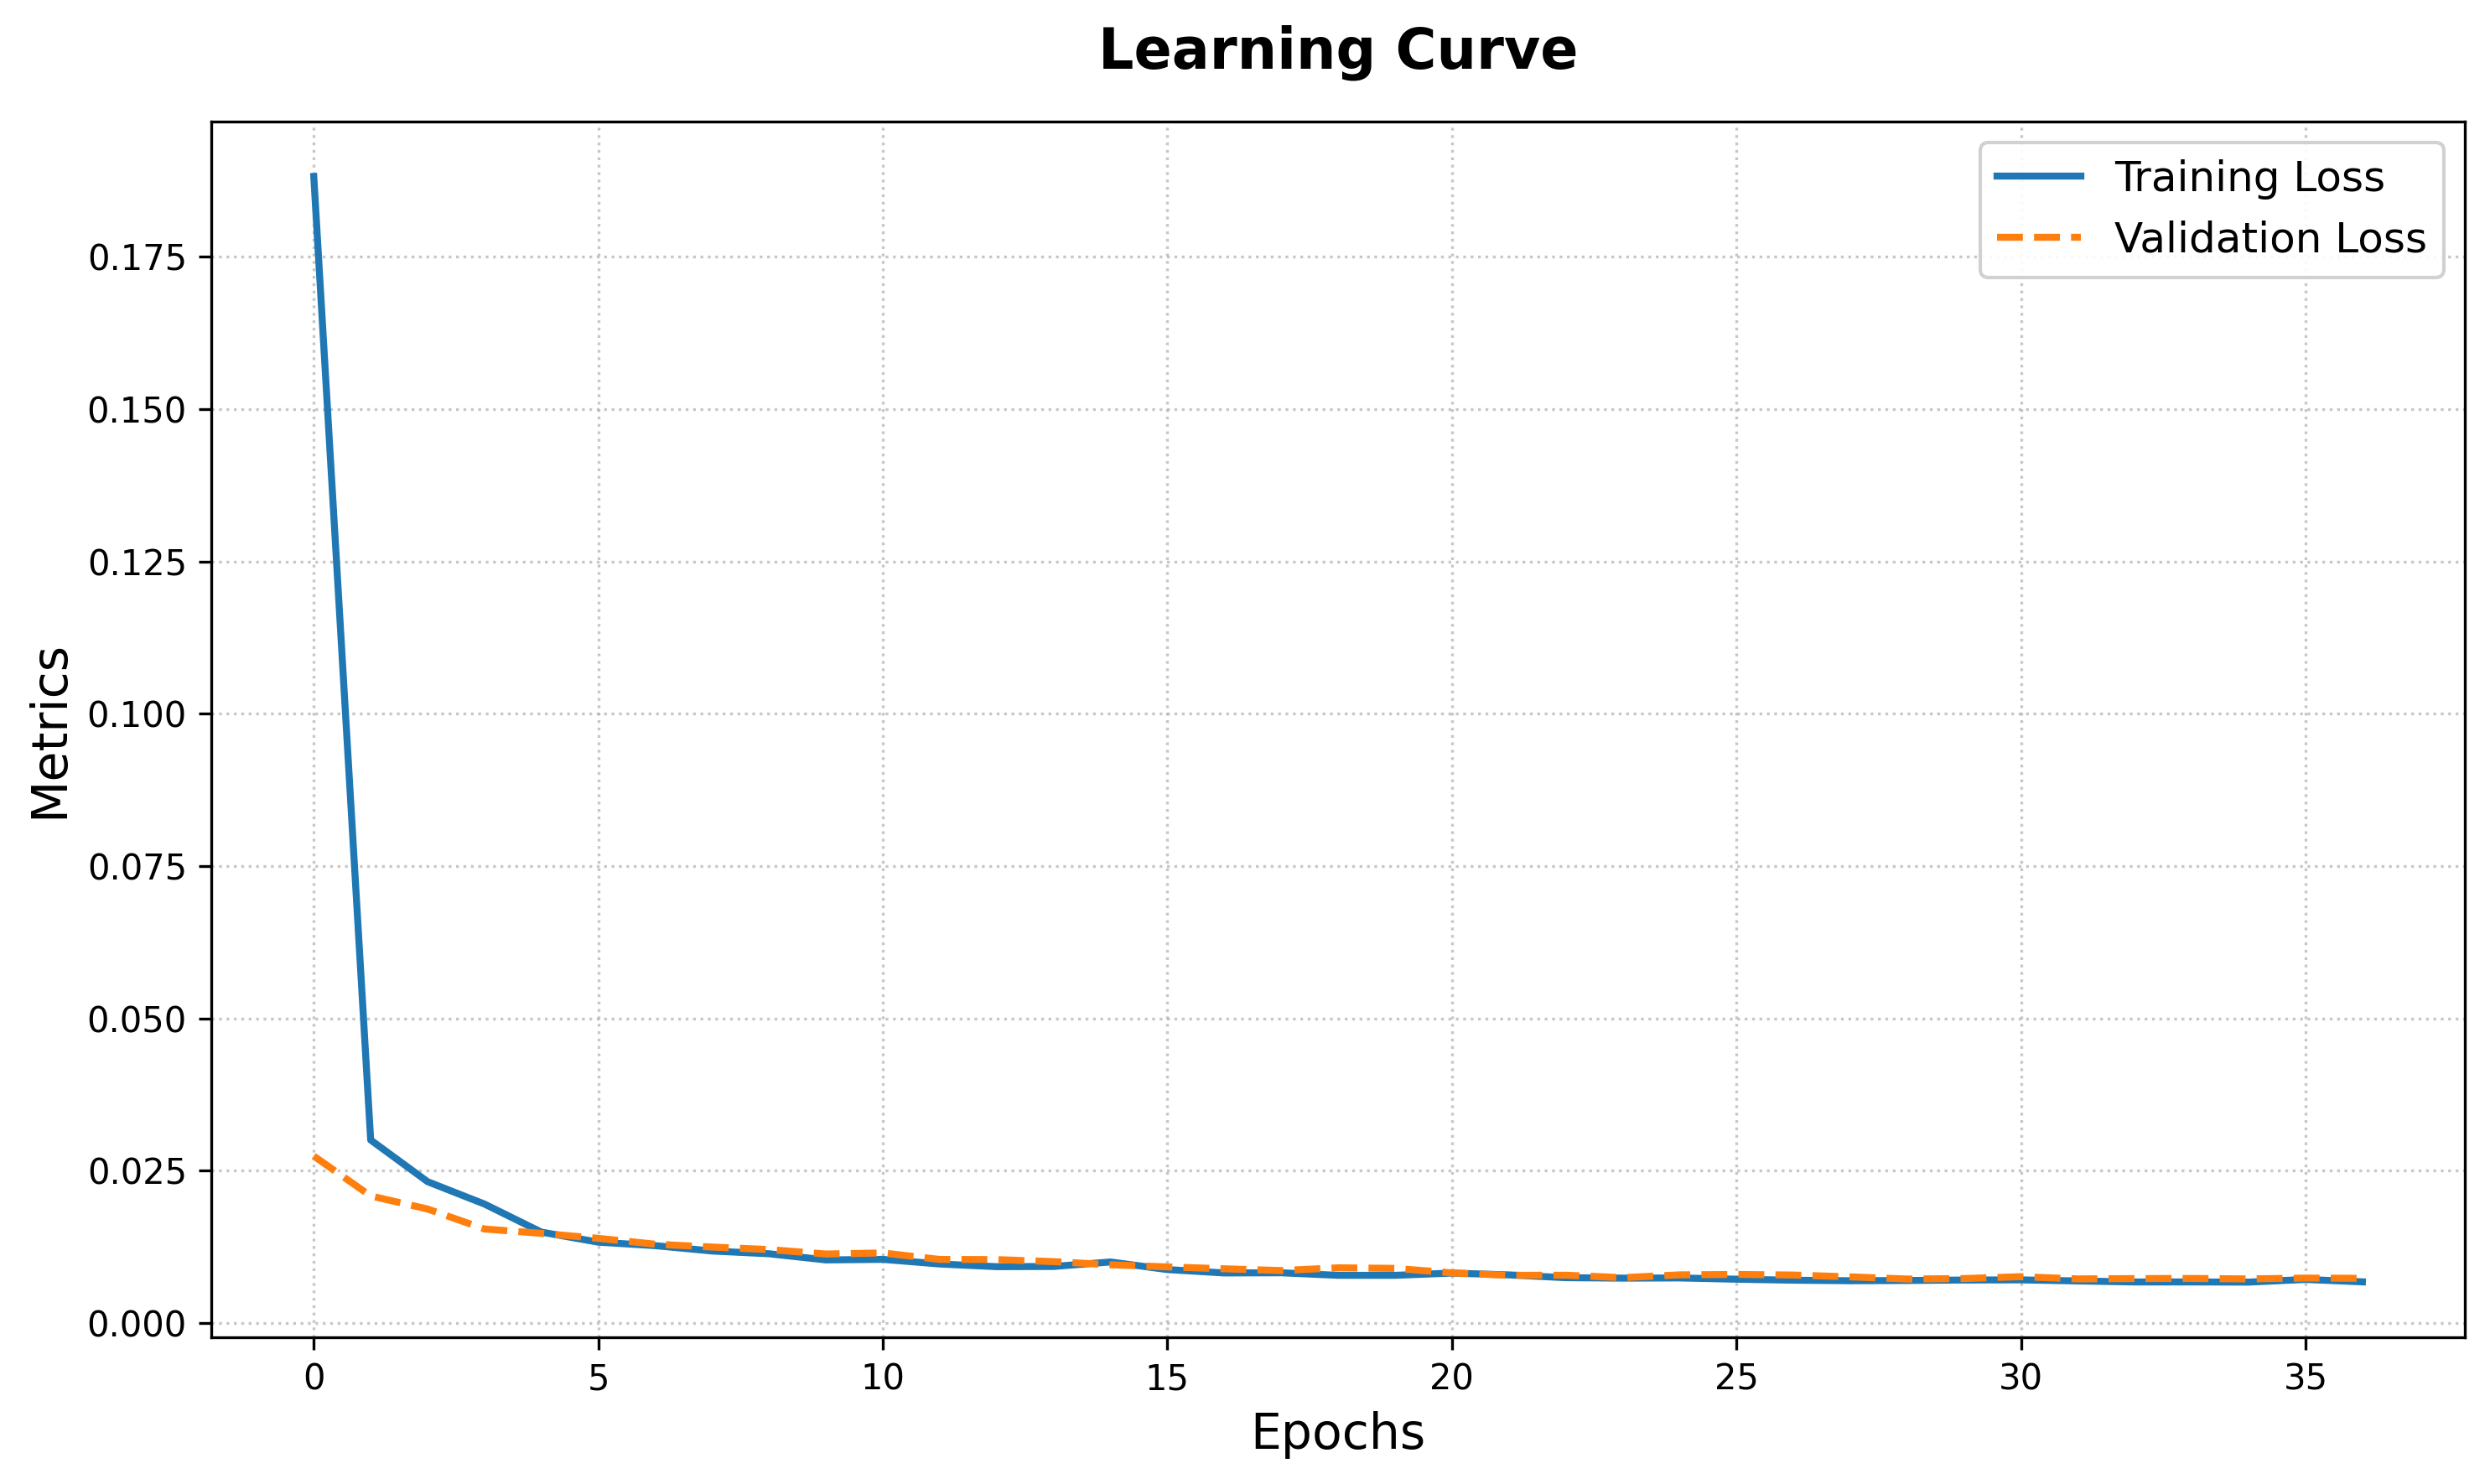

In [11]:
plot_and_save_history(training_history_2, save_dir="plots")

## Saving models

In [12]:
from time_series_utils import *

In [13]:
# Impacchettiamo gli scaler in un dizionario
my_scalers = {
    'scaler_X_flux': scaler,
    'scaler_y': scaler_y
}

save_lstm_and_scalers(
    model=trained_lstm, 
    scalers_dict=my_scalers, 
    save_dir="saved_lstm", 
    model_name="lstm_100_epochs.pth", 
    scaler_name="lstm_scalers_100_epochs.pkl"
)

save_lstm_and_scalers(
    model=trained_lstm_2, 
    scalers_dict=my_scalers, 
    save_dir="saved_lstm", 
    model_name="lstm_1000_epochs.pth", 
    scaler_name="lstm_scalers_1000_epochs.pkl"
)

Operation successfully completed!
   - Model weights saved in: saved_lstm/lstm_100_epochs_20260728_113946.pth
   - Scalers saved in:       saved_lstm/lstm_scalers_100_epochs_20260728_113946.pkl
Operation successfully completed!
   - Model weights saved in: saved_lstm/lstm_1000_epochs_20260728_113946.pth
   - Scalers saved in:       saved_lstm/lstm_scalers_1000_epochs_20260728_113946.pkl


### Creating artificial Test Set with LSTM predicted values

In [14]:
print("--- 1. Creation of the LSTM predictions DataFrame ---")

# The LSTM 'y' array starts after LOOKBACK_WINDOW days.
# split_idx defines where the Test Set begins.
start_test_idx = LOOKBACK_WINDOW + split_idx

# extracting the exact dates of the test set.
dates_for_lstm_test = df_daily['datetime'].iloc[start_test_idx:].values

# creating a DataFrame with the blind predictions from the LSTM trained for 1000 epochs.
df_lstm_blind_test = pd.DataFrame({
    'datetime': dates_for_lstm_test,
    'Predicted_F10_7': y_pred_lstm_2
})

# finding the exact date when the chronological test set begins
split_date = df_lstm_blind_test['datetime'].min()
print(f"The chronological train/test split occurs on: {split_date}")
print(f"Days in the LSTM Blind Test Set: {len(df_lstm_blind_test)}")

--- 1. Creation of the LSTM predictions DataFrame ---
The chronological train/test split occurs on: 2018-01-23 00:00:00
Days in the LSTM Blind Test Set: 1101


In [15]:
print("\n--- 2. Temporal Alignment (Asof Merge) on MARSIS data ---")

df_main_copy = df.copy(deep=True)

# filtering MARSIS, taking ONLY the data following the split date.
df_marsis_test_only = df[df['datetime'] >= split_date].copy()

# =====================================================================
# Time precision alignment [ns]
# =====================================================================
df_marsis_test_only['datetime'] = df_marsis_test_only['datetime'].astype('datetime64[ns]')
df_lstm_blind_test['datetime'] = df_lstm_blind_test['datetime'].astype('datetime64[ns]')

# setting up the asynchronous merge (the types now match perfectly).
df_marsis_test_only = df_marsis_test_only.sort_values('datetime').reset_index(drop=True)
df_lstm_blind_test = df_lstm_blind_test.sort_values('datetime').reset_index(drop=True)

# Merge: The LSTM prediction for the current/previous day is associated with each MARSIS row.
df_cascade_test = pd.merge_asof(
    df_marsis_test_only,
    df_lstm_blind_test,
    on='datetime',
    direction='backward'
)

# removing any NaNs in case of initial misalignments.
df_cascade_test = df_cascade_test.dropna(subset=['Predicted_F10_7'])
print(f" MARSIS traces in the Operational Test Set: {len(df_cascade_test)}")


--- 2. Temporal Alignment (Asof Merge) on MARSIS data ---
 MARSIS traces in the Operational Test Set: 899137


In [16]:
print("\n--- 3. Generation of Test Datasets (Ideal vs. Cascade) ---")

# SCENARIO 1: IDEAL – using real data.
df_test_ideal = df_cascade_test.copy(deep=True)

# SCENARIO 2: CASCADE – feeding the model with the LSTM estimates
df_test_cascade = df_cascade_test.copy(deep=True)
df_test_cascade['FM_data_F10_7_index'] = df_test_cascade['Predicted_F10_7']

df_test_ideal = df_test_ideal.drop(columns=['Predicted_F10_7'])
df_test_cascade = df_test_cascade.drop(columns=['Predicted_F10_7'])

# saving
os.makedirs("../Data/Test_Sets", exist_ok=True)

timestamp_safe = datetime.now().strftime("%Y%m%d_%H%M%S")

path_ideal = f"../Data/Test_Sets/MARSIS_Test_Ideal_{timestamp_safe}.csv"
path_cascade = f"../Data/Test_Sets/MARSIS_Test_Cascade_{timestamp_safe}.csv"

df_test_ideal.to_csv(path_ideal, sep=";", index=False)
df_test_cascade.to_csv(path_cascade, sep=";", index=False)

print(f"File salvati con successo in ../Data/Test_Sets/:")
print(f"- {path_ideal}")
print(f"- {path_cascade}")


--- 3. Generation of Test Datasets (Ideal vs. Cascade) ---
File salvati con successo in ../Data/Test_Sets/:
- ../Data/Test_Sets/MARSIS_Test_Ideal_20260728_114017.csv
- ../Data/Test_Sets/MARSIS_Test_Cascade_20260728_114017.csv


In [17]:
from utils.data_processing import *

# =====================================================================
# STEP 1: GENERATION OF THE TRAINING SET (THE CHRONOLOGICALLY EARLIER 80%)
# =====================================================================
print("--- 1. Isolation and recovery of the train set (80%) ---")

# taking the historical data prior to the LSTM split date.
df_marsis_train_only = df[df['datetime'] < split_date].copy()

# removing the auxiliary 'datetime' column to restore the original MARSIS format.
df_marsis_train_only = df_marsis_train_only.drop(columns=['datetime'], errors='ignore')

timestamp_export = datetime.now().strftime("%Y%m%d_%H%M%S")
train_csv_path = f"../Data/Test_Sets/MARSIS_Train_Pure_{timestamp_export}.csv"
df_marsis_train_only.to_csv(train_csv_path, sep=";", index=False)
print(f"Original Train Set saved in: {train_csv_path}")


# =====================================================================
# STEP 2: Cleaning and saving test datasets
# =====================================================================
print("\n--- 2. Adjustment and preservation of test sets (Ideal and Cascade) ---")

# cleaning 'datetime' column
df_test_ideal_save = df_test_ideal.drop(columns=['datetime'], errors='ignore')
df_test_cascade_save = df_test_cascade.drop(columns=['datetime'], errors='ignore')

ideal_csv_path = f"../Data/Test_Sets/MARSIS_Test_Ideal_{timestamp_export}.csv"
cascade_csv_path = f"../Data/Test_Sets/MARSIS_Test_Cascade_{timestamp_export}.csv"

# Saving
df_test_ideal_save.to_csv(ideal_csv_path, sep=";", index=False)
df_test_cascade_save.to_csv(cascade_csv_path, sep=";", index=False)
print("Test files successfully saved and ready for the pipeline.")


# =====================================================================
# STEP 3: Extraction of matrices X and y via load_and_preprocess_data
# =====================================================================

print("\n--- 3. Extraction of final matrices using the standard pipeline ---")

orbit_file_path = "../Data/orbit_to_remove" 

# 1. training dataset (true solar flux)
X_train, y_train, feature_names = load_and_preprocess_data(
    dataset_path=train_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True 
)

# 2. Ideal Test Dataset 
X_test_ideal, y_test_ideal, _ = load_and_preprocess_data(
    dataset_path=ideal_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True
)

# 3. Cascade Test Dataset 
X_test_cascade, y_test_cascade, _ = load_and_preprocess_data(
    dataset_path=cascade_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True
)


# =====================================================================
# STEP 4: checking
# =====================================================================
print("\n" + "="*50)
print("Verification of dataset dimensions and feature consistency")
print("="*50)
print(f"Used Features ({len(feature_names)}): {feature_names}")
print("-" * 50)
print(f"TRAIN SET              -> X: {X_train.shape}  | y: {y_train.shape}")
print(f"TEST SET (IDEAL)     -> X: {X_test_ideal.shape}  | y: {y_test_ideal.shape}")
print(f"TEST SET (CASCADE)    -> X: {X_test_cascade.shape}  | y: {y_test_cascade.shape}")
print("-" * 50)

assert X_test_ideal.shape == X_test_cascade.shape, "ERROR: Misalignment between Ideal Test and Cascade!"
assert np.array_equal(y_test_ideal, y_test_cascade), "ERROR: The test targets (Echo Power) do not match!"
print("Everything is ready! The matrices are aligned.")

--- 1. Isolation and recovery of the train set (80%) ---
Original Train Set saved in: ../Data/Test_Sets/MARSIS_Train_Pure_20260728_114325.csv

--- 2. Adjustment and preservation of test sets (Ideal and Cascade) ---
Test files successfully saved and ready for the pipeline.

--- 3. Extraction of final matrices using the standard pipeline ---

Verification of dataset dimensions and feature consistency
Used Features (19): ['FM_data_altitude', 'FM_data_band', 'FM_data_dipole_tilt', 'FM_data_F10_7_index', 'FM_data_latitude', 'FM_data_local_true_solar_time', 'FM_data_longitude', 'FM_data_Mars_Sun_distance', 'FM_data_monopole_tilt', 'FM_data_radial_magnetic_field', 'FM_data_roughness', 'FM_data_slope', 'FM_data_Sun_elevation_angle', 'FM_data_tangential_magnetic_field', 'FM_data_total_magnetic_field', 'FM_data_x_coordinate', 'FM_data_y_coordinate', 'FM_data_solar_longitude_cos', 'FM_data_solar_longitude_sin']
--------------------------------------------------
TRAIN SET              -> X: (14741

### Model training

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import torch
import os
from datetime import datetime
from joblib import dump
from models.neural_network import *

print("--- 1. Feature Standardization ---")

scaler_nn = StandardScaler()

X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_ideal_scaled = scaler_nn.transform(X_test_ideal)
X_test_cascade_scaled = scaler_nn.transform(X_test_cascade)

--- 1. Feature Standardization ---


In [ ]:
print("--- 2. Training NeurNet ---")

input_dimension = X_train_scaled.shape[1]

main_model, device, history = train_pytorch_model(
    X_train=X_train_scaled, 
    y_train=y_train, 
    input_dim=input_dimension, 
    model_class=NeurNet,  
    epochs=1000, 
    patience=10, 
    batch_size=256
)

# Saving
os.makedirs("saved_main_model", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
scaler_save_path = f"saved_main_model/main_nn_scaler_{timestamp}.save"
torch.save(main_model.state_dict(), f"saved_main_model/main_nn_model_{timestamp}.pth")
dump(scaler_nn, scaler_save_path)
print("Main Model trained and saved.")
print(f"Corresponding scaler saved in: {scaler_save_path}")

--- 1. Feature Standardization ---
--- 2. Training NeurNet ---


Early stopping at epoch 16
Main Model trained and saved.
Corresponding scaler saved in: saved_main_model/main_nn_scaler_20260726_201714.save



Plots successfully saved to:
- plots/training_history_20260726_202402.png
- plots/training_history_20260726_202402.pdf


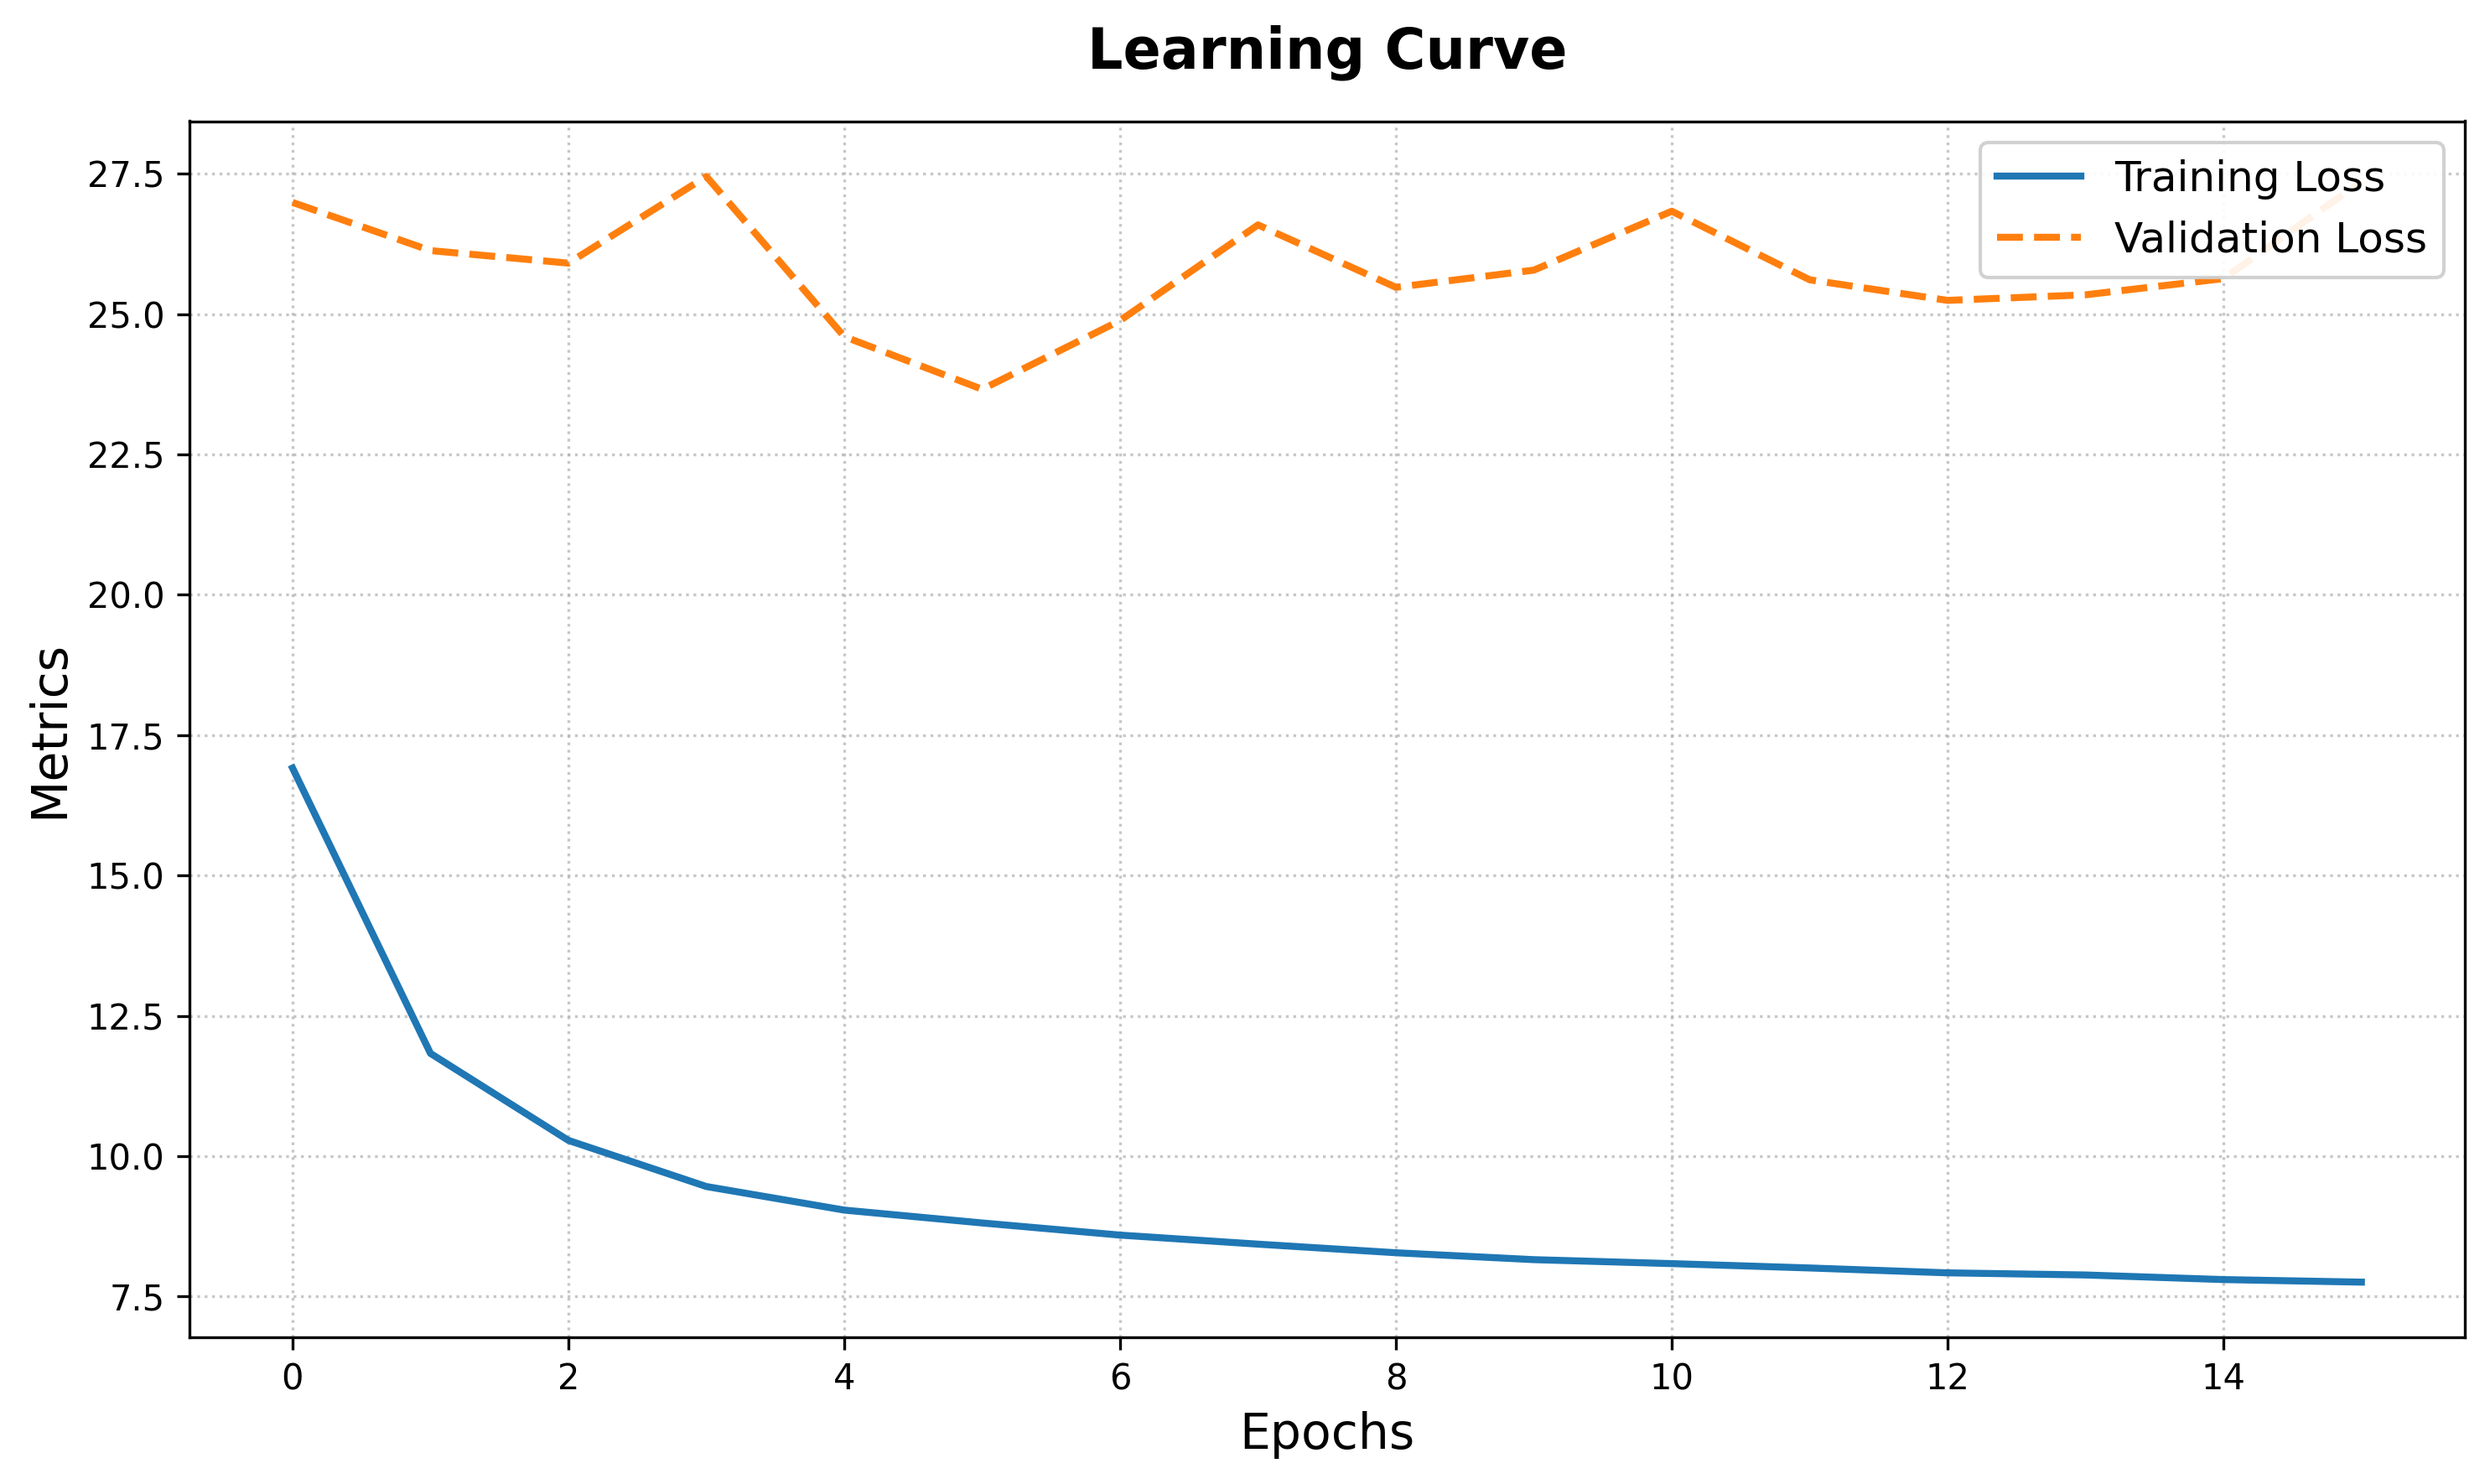

In [19]:
plot_and_save_history(history, save_dir="plots")

### Testing model on true data and on artificially engineered (LSTM) data


--- Comparative Assessment of the Two Scenarios (Ideal vs. Waterfall) ---
Final Report: performance of cascade experiment
SCENARIO 1: True Solar Flux
  MAE:  2.7174
  RMSE: 3.4049
------------------------------------------------------------
SCENARIO 2: Solar Flux from LSTM
  MAE:  2.7196
  RMSE: 3.4050
Performance degradation caused by the post-LSTM cascade:
   Increase in MAE:  +0.08%
   Increase in RMSE: +0.00%

Generating plot...


/tmp/ipykernel_607186/3376862310.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  main_model.load_state_dict(torch.load(model_path, map_location=find_device))


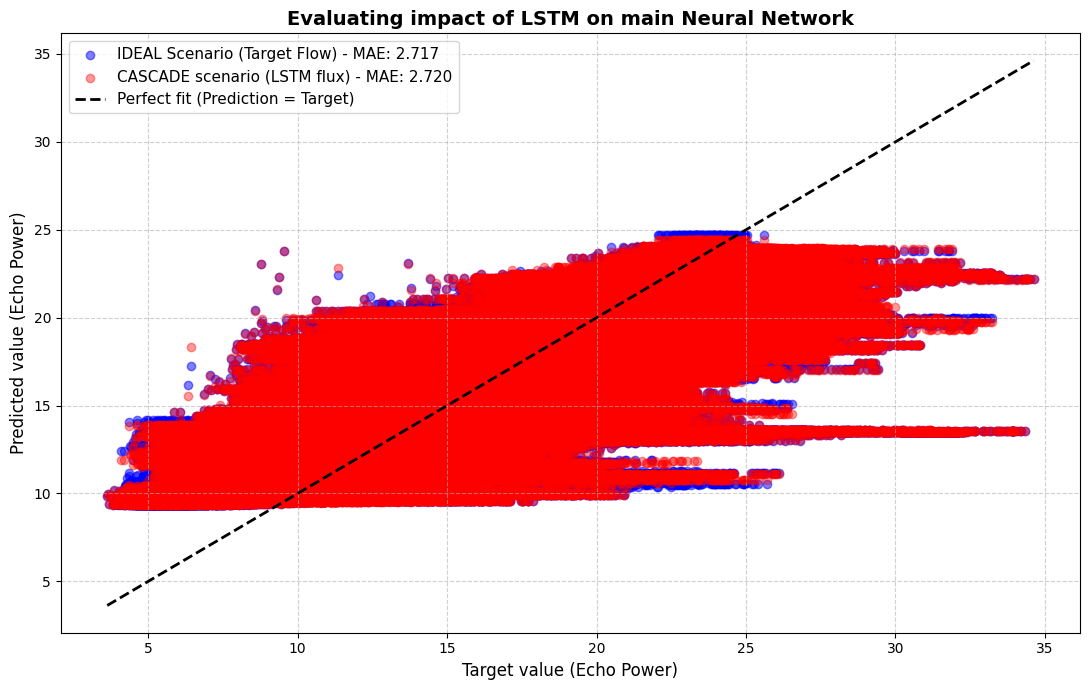

In [19]:
import matplotlib.pyplot as plt
from joblib import load
from models.neural_network import *

print("\n--- Comparative Assessment of the Two Scenarios (Ideal vs. Waterfall) ---")

model_path = "saved_main_model/main_nn_model_20260726_201714.pth" 
scaler_path = "saved_main_model/main_nn_scaler_20260726_201714.save"

input_dimension_copy = X_train_scaled.shape[1]

loaded_scaler = load(scaler_path)

find_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dimension_load = X_test_ideal.shape[1]
main_model= NeurNet(input_dim=input_dimension_copy)
main_model.load_state_dict(torch.load(model_path, map_location=find_device))
main_model.to(find_device)
main_model.eval()

X_ideal_tensor = torch.tensor(X_test_ideal_scaled, dtype=torch.float32).to(find_device)
X_cascade_tensor = torch.tensor(X_test_cascade_scaled, dtype=torch.float32).to(find_device)

with torch.no_grad():
    y_pred_ideal = main_model(X_ideal_tensor).cpu().numpy().flatten()
    y_pred_cascade = main_model(X_cascade_tensor).cpu().numpy().flatten()

# ideal
mae_ideal = mean_absolute_error(y_test_ideal, y_pred_ideal)
rmse_ideal = np.sqrt(mean_squared_error(y_test_ideal, y_pred_ideal))

# cascade
mae_cascade = mean_absolute_error(y_test_cascade, y_pred_cascade)
rmse_cascade = np.sqrt(mean_squared_error(y_test_cascade, y_pred_cascade))

print("="*60)
print("Final Report: performance of cascade experiment")
print("="*60)
print("SCENARIO 1: True Solar Flux")
print(f"  MAE:  {mae_ideal:.4f}")
print(f"  RMSE: {rmse_ideal:.4f}")
print("-" * 60)
print("SCENARIO 2: Solar Flux from LSTM")
print(f"  MAE:  {mae_cascade:.4f}")
print(f"  RMSE: {rmse_cascade:.4f}")
print("="*60)

mae_degradation = ((mae_cascade - mae_ideal) / mae_ideal) * 100
rmse_degradation = ((rmse_cascade - rmse_ideal) / rmse_ideal) * 100

print(f"Performance degradation caused by the post-LSTM cascade:")
print(f"   Increase in MAE:  +{mae_degradation:.2f}%")
print(f"   Increase in RMSE: +{rmse_degradation:.2f}%")
print("="*60)

print("\nGenerating plot...")

plt.figure(figsize=(11, 7))

plt.scatter(y_test_ideal, y_pred_ideal, alpha=0.5, color='blue', 
            label=f'IDEAL Scenario (Target Flow) - MAE: {mae_ideal:.3f}')

# Plot of the waterfall scenario (overlaid red points)
plt.scatter(y_test_cascade, y_pred_cascade, alpha=0.4, color='red', 
            label=f'CASCADE scenario (LSTM flux) - MAE: {mae_cascade:.3f}')

plt.plot([y_test_ideal.min(), y_test_ideal.max()], 
         [y_test_ideal.min(), y_test_ideal.max()], 
         'k--', lw=2, label='Perfect fit (Prediction = Target)')


plt.title('Evaluating impact of LSTM on main Neural Network', fontsize=14, fontweight='bold')
plt.xlabel('Target value (Echo Power)', fontsize=12)
plt.ylabel('Predicted value (Echo Power)', fontsize=12)

plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Solar flux prediction with LSTM and comparison with real targets

--- 1. Start of K-Fold Cross Validation for LSTM ---

>> Running Fold 1/5...


Training:   0%|                                                                                                                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 31
   Target mean: 80.22 | Predicted mean: 80.46 | Saved as predictions_fold_1_20260728_121027.csv

>> Running Fold 2/5...


Early stopping at epoch 48
   Target mean: 75.72 | Predicted mean: 75.82 | Saved as predictions_fold_2_20260728_121027.csv

>> Running Fold 3/5...


Early stopping at epoch 48
   Target mean: 145.47 | Predicted mean: 144.40 | Saved as predictions_fold_3_20260728_121027.csv

>> Running Fold 4/5...


Early stopping at epoch 49
   Target mean: 119.04 | Predicted mean: 118.98 | Saved as predictions_fold_4_20260728_121027.csv

>> Running Fold 5/5...


Early stopping at epoch 47
   Target mean: 78.62 | Predicted mean: 78.52 | Saved as predictions_fold_5_20260728_121027.csv

--- 2. Generation of Distribution Charts (Histograms) ---
Plot saved with high resolution in:
 - plots/histograms_folds_20260728_121027.png
 - plots/histograms_folds_20260728_121027.pdf


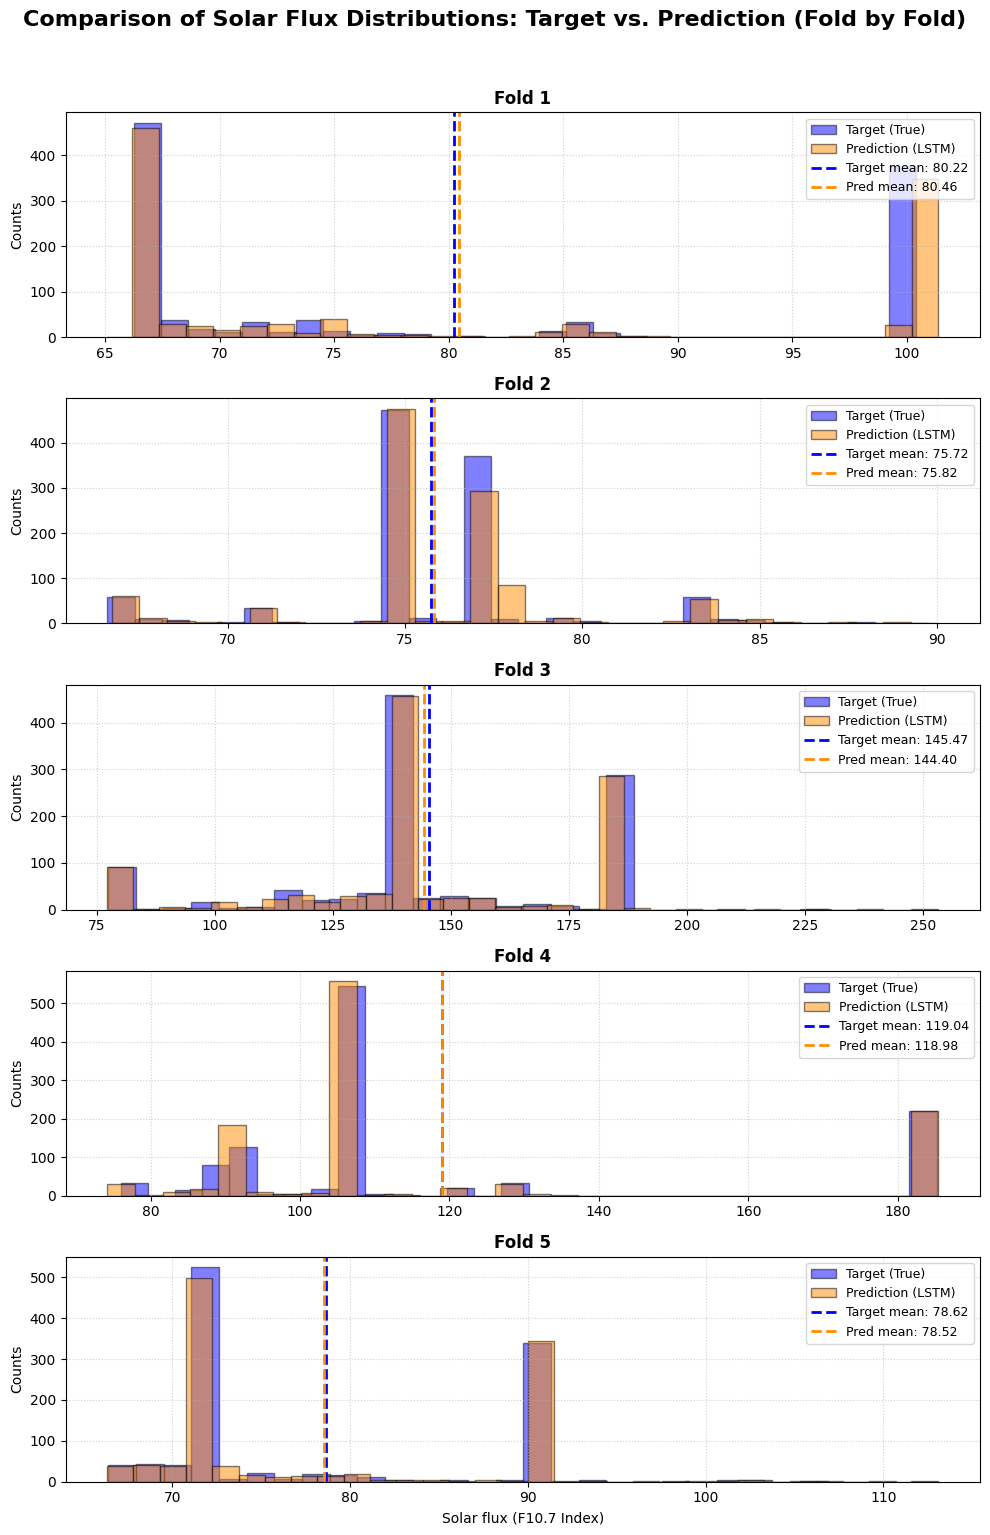

In [21]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from models.LSTM import LSTMRegressor
from utils.train_pytorch_model import train_pytorch_model
from datetime import datetime
from joblib import dump

print("--- 1. Start of K-Fold Cross Validation for LSTM ---")

# defining a 5-fold split without shuffling (time blocks)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

# Dictionaries to save the results of each fold
fold_results = {}

timestamp_exp = datetime.now().strftime("%Y%m%d_%H%M%S")
y_unscaled = y.reshape(-1, 1)

fold = 1
for train_idx, test_idx in kf.split(y_unscaled):
    print(f"\n>> Running Fold {fold}/{n_splits}...")
    
    X_train_flux, X_test_flux = X_flux[train_idx], X_flux[test_idx]
    X_train_time, X_test_time = X_time[train_idx], X_time[test_idx]
    y_train_f, y_test_f = y_unscaled[train_idx], y_unscaled[test_idx]

    scaler_flux = StandardScaler()
    scaler_flux_y = StandardScaler()

    X_train_flux_scaled = scaler_flux.fit_transform(X_train_flux)
    y_train_scaled = scaler_flux_y.fit_transform(y_train_f)

    X_test_flux_scaled = scaler_flux.transform(X_test_flux)

    X_train_flux_3d = np.expand_dims(X_train_flux_scaled, axis=-1)
    X_test_flux_3d = np.expand_dims(X_test_flux_scaled, axis=-1)

    X_train_final = np.concatenate((X_train_flux_3d, X_train_time), axis=-1)
    X_test_final = np.concatenate((X_test_flux_3d, X_test_time), axis=-1)
    
    # training a new LSTM for this fold
    model_f, device_f, _ = train_pytorch_model(
        X_train=X_train_final, y_train=y_train_scaled, input_dim=3,
        model_class=LSTMRegressor, epochs=1000, patience=8, 
        batch_size=64, hidden_dim=256
    )
    
    # inference
    model_f.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32).to(device_f)
        y_pred_scaled = model_f(X_test_tensor).cpu().numpy()
    
    # Denormalization
    y_pred_real = scaler_flux_y.inverse_transform(y_pred_scaled).flatten()
    y_target_real = y_test_f.flatten()
    
    # Calculating the averages required for this fold
    mean_target = np.mean(y_target_real)
    mean_pred = np.mean(y_pred_real)
    
    # Saving data
    fold_results[fold] = {
        'targets': y_target_real,
        'preds': y_pred_real,
        'mean_target': mean_target,
        'mean_pred': mean_pred
    }

    df_fold = pd.DataFrame({
        'Target_F10_7': y_target_real,
        'Predicted_F10_7': y_pred_real
    })
    
    file_name = f"predictions_fold_{fold}_{timestamp_exp}.csv"
    
    # Saving on disk
    df_fold.to_csv(file_name, index=False)
    dump(scaler_flux, f'scaler_flux_fold_{fold}_{timestamp_exp}.save')
    dump(scaler_flux_y, f'scaler_target_fold_{fold}_{timestamp_exp}.save')

    model_save_path = f"lstm_model_fold_{fold}_{timestamp_exp}.pt"
    torch.save(model_f.state_dict(), model_save_path)
    
    print(f"   Target mean: {mean_target:.2f} | Predicted mean: {mean_pred:.2f} | Saved as {file_name}")

    fold += 1

print("\n--- 2. Generation of Distribution Charts (Histograms) ---")

# creating a plot with N rows (one per fold)
fig, axes = plt.subplots(nrows=n_splits, ncols=1, figsize=(10, 3 * n_splits))
fig.suptitle("Comparison of Solar Flux Distributions: Target vs. Prediction (Fold by Fold)", fontsize=16, fontweight='bold', y=1.02)

for i in range(1, n_splits + 1):
    ax = axes[i-1]
    data = fold_results[i]
    
    ax.hist(data['targets'], bins=30, alpha=0.5, color='blue', label='Target (True)', edgecolor='black')
    ax.hist(data['preds'], bins=30, alpha=0.5, color='darkorange', label='Prediction (LSTM)', edgecolor='black')
    
    ax.axvline(data['mean_target'], color='blue', linestyle='dashed', linewidth=2, label=f"Target mean: {data['mean_target']:.2f}")
    ax.axvline(data['mean_pred'], color='darkorange', linestyle='dashed', linewidth=2, label=f"Pred mean: {data['mean_pred']:.2f}")
    
    ax.set_title(f"Fold {i}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Counts")
    if i == n_splits:
        ax.set_xlabel("Solar flux (F10.7 Index)")
    
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plot_filename_exp_png = f"plots/histograms_folds_{timestamp_exp}.png"
plot_filename_exp_pdf = f"plots/histograms_folds_{timestamp_exp}.pdf"
plt.savefig(plot_filename_exp_png, format='png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(plot_filename_exp_pdf, format='pdf', bbox_inches='tight', facecolor='white')
print(f"Plot saved with high resolution in:\n - {plot_filename_exp_png}\n - {plot_filename_exp_pdf}")
plt.show()


--- 3. Generation of Time-Series Plots and Wasserstein Calculation ---
Plot of trend saved successfully in: plots/temporal_evolution_wasserstein_20260728_153349.pdf
Plot of trend (PNG) saved successfully in: plots/temporal_evolution_wasserstein_20260728_153349.png
Histogram plot saved successfully in: plots/histOf_distributions_20260728_153349.pdf
Histogram plot (PNG) saved successfully in: plots/histOf_distributions_20260728_153349.png


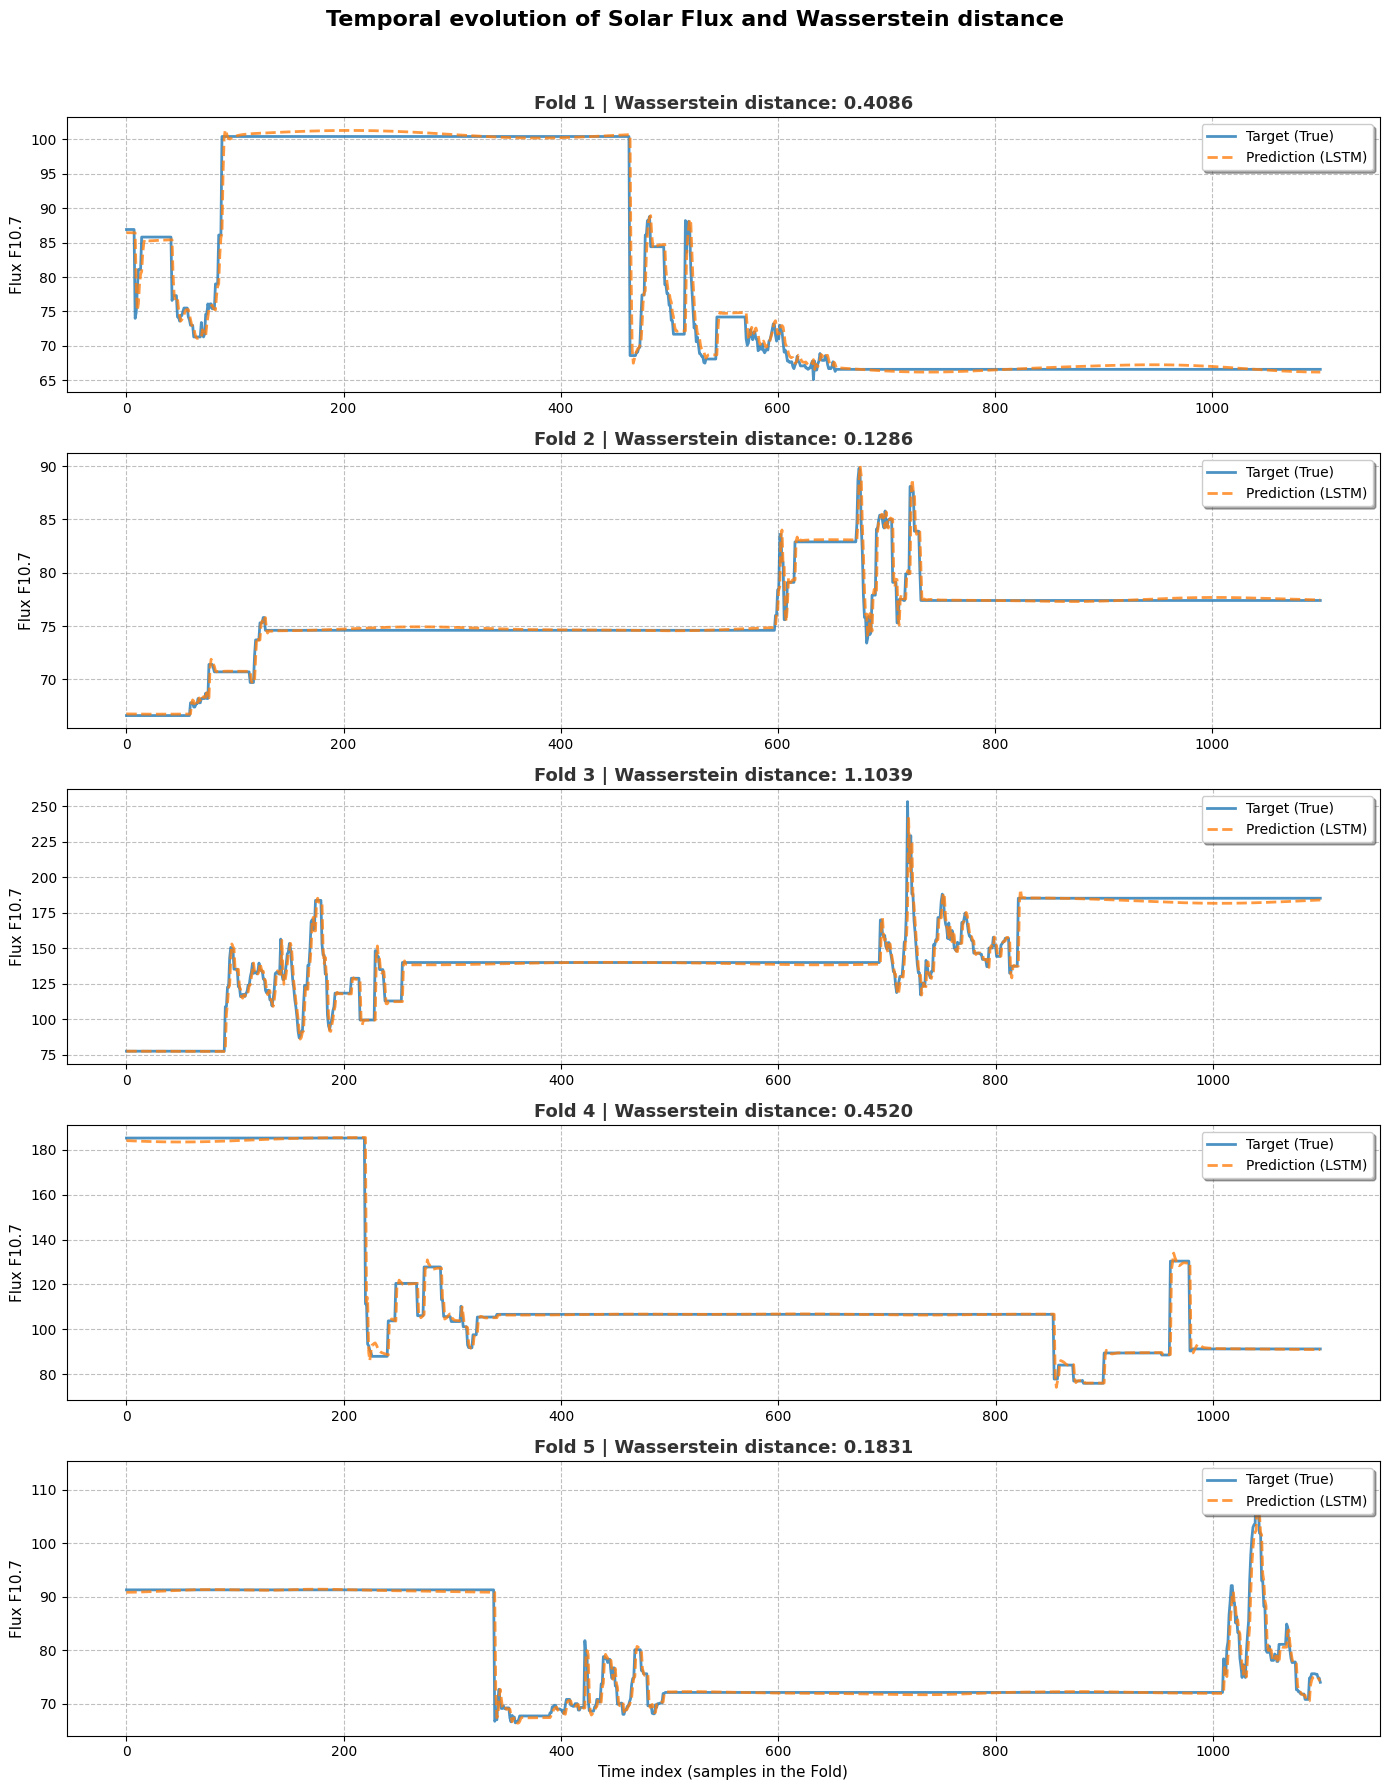

In [22]:
# =====================================================================
# --- 3. Temporal Evolution and Wasserstein Distance (New Block) ---
# =====================================================================
from scipy.stats import wasserstein_distance

print("\n--- 3. Generation of Time-Series Plots and Wasserstein Calculation ---")

fig_line, axes_line = plt.subplots(nrows=n_splits, ncols=1, figsize=(14, 3.5 * n_splits))
fig_line.suptitle("Temporal evolution of Solar Flux and Wasserstein distance", 
                  fontsize=16, fontweight='bold', y=1.02)

for i in range(1, n_splits + 1):
    # Safe axis handling if n_splits is 1
    ax = axes_line[i-1] if n_splits > 1 else axes_line
    
    # Retrieving data from the previously populated dictionary
    data = fold_results[i]
    y_t = data['targets']
    y_p = data['preds']
    
    # calculating Wasserstein distance
    w_dist = wasserstein_distance(y_t, y_p)
    
    ax.plot(y_t, label='Target (True)', color='#1f77b4', linewidth=2, alpha=0.8)
    ax.plot(y_p, label='Prediction (LSTM)', color='#ff7f0e', linewidth=2, alpha=0.8, linestyle='--')
    
    ax.set_title(f"Fold {i} | Wasserstein distance: {w_dist:.4f}", fontsize=13, fontweight='bold', color='#333333')
    ax.set_ylabel("Flux F10.7", fontsize=11)
    
    if i == n_splits:
        ax.set_xlabel("Time index (samples in the Fold)", fontsize=11)
        
    ax.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()

timestamp_exp_1 = datetime.now().strftime("%Y%m%d_%H%M%S")

# saving in pdf format with unique timestamp
os.makedirs("plots", exist_ok=True)
pdf_filename_line = f"plots/temporal_evolution_wasserstein_{timestamp_exp_1}.pdf"
fig_line.savefig(pdf_filename_line, format='pdf', bbox_inches='tight', dpi=600, facecolor='white')
print(f"Plot of trend saved successfully in: {pdf_filename_line}")

png_filename_line = f"plots/temporal_evolution_wasserstein_{timestamp_exp_1}.png"
fig_line.savefig(png_filename_line, format='png', bbox_inches='tight', dpi=600, facecolor='white')
print(f"Plot of trend (PNG) saved successfully in: {png_filename_line}")

pdf_filename_hist = f"plots/histOf_distributions_{timestamp_exp_1}.pdf"
fig.savefig(pdf_filename_hist, format='pdf', bbox_inches='tight', dpi=600, facecolor='white')
print(f"Histogram plot saved successfully in: {pdf_filename_hist}")

png_filename_hist = f"plots/histOf_distributions_{timestamp_exp_1}.png"
fig.savefig(png_filename_hist, format='png', bbox_inches='tight', dpi=600, facecolor='white')
print(f"Histogram plot (PNG) saved successfully in: {png_filename_hist}")

plt.show()

## Monthly prediction of the F10.7 Solar Flux using a neural network and engineered features

In [25]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime

from models.LSTM import LSTMRegressor
from models.neural_network import NeurNet 
from utils.train_pytorch_model import train_pytorch_model
from utils.data_processing import load_and_preprocess_data

In [26]:
# Preparing the time indices for the expanding window
# 'y' starts after LOOKBACK_WINDOW days.
valid_dates = df_daily['datetime'].iloc[LOOKBACK_WINDOW:].reset_index(drop=True)

# creating a series labeled "Year-Month" to allow for month-by-month iteration
valid_months = valid_dates.dt.to_period('M')
unique_months = valid_months.unique()

# deciding where to start the simulation (e.g., the last 20% of the available months)
start_month_idx = int(len(unique_months) * 0.8)

print(f"Total months available: {len(unique_months)}")
print(f"The walk-forward simulation will start from the month of: {unique_months[start_month_idx]}")

print("\n=== Walk-Forward Validation (Expanding Window) on LSTM ===")

walk_forward_preds = []
walk_forward_dates = []

Total months available: 181
The walk-forward simulation will start from the month of: 2018-01

=== Walk-Forward Validation (Expanding Window) on LSTM ===


In [27]:
# iterating month by month
for i in range(start_month_idx, len(unique_months)):
    target_month = unique_months[i]
    print(f"\n>> Training until: {target_month - 1} | Prediction for: {target_month}")
    
    # dividing past (Train) and present (Test)
    train_mask = valid_months < target_month
    test_mask = valid_months == target_month
    
    # Slicing true data
    X_flux_train_wf = X_flux[train_mask]
    X_time_train_wf = X_time[train_mask]
    y_train_wf = y[train_mask]
    
    X_flux_test_wf = X_flux[test_mask]
    X_time_test_wf = X_time[test_mask]
    y_test_wf = y[test_mask]
    dates_test_wf = valid_dates[test_mask]
    
    scaler_X_flux_wf = StandardScaler()
    scaler_y_wf = StandardScaler()
    
    # scaling target
    y_train_scaled_wf = scaler_y_wf.fit_transform(y_train_wf.reshape(-1, 1))
    
    # scaling flux
    X_flux_train_scaled = scaler_X_flux_wf.fit_transform(X_flux_train_wf)
    X_flux_test_scaled = scaler_X_flux_wf.transform(X_flux_test_wf)
    
    # adding last dimension
    X_flux_train_3d_wf = np.expand_dims(X_flux_train_scaled, axis=-1)
    X_flux_test_3d_wf = np.expand_dims(X_flux_test_scaled, axis=-1)
    
    X_lstm_train_wf = np.concatenate((X_flux_train_3d_wf, X_time_train_wf), axis=-1)
    X_lstm_test_wf = np.concatenate((X_flux_test_3d_wf, X_time_test_wf), axis=-1)
    
    # training LSTM
    model_wf, device_wf, _ = train_pytorch_model(
        X_train=X_lstm_train_wf, 
        y_train=y_train_scaled_wf, 
        input_dim=3,                
        model_class=LSTMRegressor, 
        epochs=1000, patience=8, 
        batch_size=64, hidden_dim=256
    )
    
    # Inference
    model_wf.eval()
    with torch.no_grad():
        X_test_tensor_wf = torch.tensor(X_lstm_test_wf, dtype=torch.float32).to(device_wf)
        y_pred_scaled_wf = model_wf(X_test_tensor_wf).cpu().numpy()
        
    y_pred_real_wf = scaler_y_wf.inverse_transform(y_pred_scaled_wf).flatten()
    
    # Saving
    walk_forward_preds.extend(y_pred_real_wf)
    walk_forward_dates.extend(dates_test_wf.values)


>> Training until: 2017-12 | Prediction for: 2018-01


Training:   0%|                                                                                                                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 42

>> Training until: 2018-01 | Prediction for: 2018-02


Early stopping at epoch 45

>> Training until: 2018-02 | Prediction for: 2018-03


Early stopping at epoch 46

>> Training until: 2018-03 | Prediction for: 2018-04


...

Early stopping at epoch 37

>> Training until: 2020-09 | Prediction for: 2020-10


Early stopping at epoch 35

>> Training until: 2020-10 | Prediction for: 2020-11


Early stopping at epoch 17

>> Training until: 2020-11 | Prediction for: 2020-12


Early stopping at epoch 39

>> Training until: 2020-12 | Prediction for: 2021-01


Early stopping at epoch 51


In [28]:
print("\n=== Data replacement and merge (Cascade) ===")

# creating the DataFrame containing all the Walk-Forward predictions
df_wf_blind_test = pd.DataFrame({
    'datetime': walk_forward_dates,
    'Predicted_F10_7': walk_forward_preds
})
split_date_wf = df_wf_blind_test['datetime'].min()

# filtering the deep copy of MARSIS to select only the test period
df_main_copy['datetime'] = pd.to_datetime(df_main_copy['FM_data_ephemeris_time'], unit='s', origin=pd.Timestamp('2000-01-01 12:00:00'))
df_marsis_test_wf = df_main_copy[df_main_copy['datetime'] >= split_date_wf].copy()

# Nanosecond time alignment
df_marsis_test_wf['datetime'] = df_marsis_test_wf['datetime'].astype('datetime64[ns]')
df_wf_blind_test['datetime'] = df_wf_blind_test['datetime'].astype('datetime64[ns]')

df_marsis_test_wf = df_marsis_test_wf.sort_values('datetime').reset_index(drop=True)
df_wf_blind_test = df_wf_blind_test.sort_values('datetime').reset_index(drop=True)

# Merge: associating the monthly predictions with the radar
df_cascade_wf = pd.merge_asof(
    df_marsis_test_wf,
    df_wf_blind_test,
    on='datetime',
    direction='backward'
)
df_cascade_wf = df_cascade_wf.dropna(subset=['Predicted_F10_7'])

# true (ideal) data
df_test_ideal_wf = df_cascade_wf.copy(deep=True)

# cascade (LSTM predicted) data
df_test_cascade_wf = df_cascade_wf.copy(deep=True)
df_test_cascade_wf['FM_data_F10_7_index'] = df_test_cascade_wf['Predicted_F10_7']

# removing the support columns before saving
df_test_ideal_wf = df_test_ideal_wf.drop(columns=['Predicted_F10_7', 'datetime'], errors='ignore')
df_test_cascade_wf = df_test_cascade_wf.drop(columns=['Predicted_F10_7', 'datetime'], errors='ignore')

timestamp_wf = datetime.now().strftime("%Y%m%d_%H%M%S")

os.makedirs("../Data/Test_sets", exist_ok=True)

ideal_csv_path = f"../Data/Test_Sets/MARSIS_Test_Ideal_WF_{timestamp_wf}.csv"
cascade_csv_path = f"../Data/Test_Sets/MARSIS_Test_Cascade_WF_{timestamp_wf}.csv"
train_csv_path = f"../Data/Test_Sets/MARSIS_Train_Pure_WF_{timestamp_wf}.csv"

df_test_ideal_wf.to_csv(ideal_csv_path, sep=";", index=False)
df_test_cascade_wf.to_csv(cascade_csv_path, sep=";", index=False)

# using the period prior to the split_date to train the neural network and clean the data.
df_marsis_train_wf = df_main_copy[df_main_copy['datetime'] < split_date_wf].copy()
df_marsis_train_wf = df_marsis_train_wf.drop(columns=['datetime'], errors='ignore')

# saving train file
df_marsis_train_wf.to_csv(train_csv_path, sep=";", index=False)

print(f"File saved:\n- {ideal_csv_path}\n- {cascade_csv_path}\n- {train_csv_path}")


=== Data replacement and merge (Cascade) ===
File saved:
- ../Data/Test_Sets/MARSIS_Test_Ideal_WF_20260728_195333.csv
- ../Data/Test_Sets/MARSIS_Test_Cascade_WF_20260728_195333.csv
- ../Data/Test_Sets/MARSIS_Train_Pure_WF_20260728_195333.csv



=== Extraction, NN Training, and Final Evaluation ===


Early stopping at epoch 15

Model and Scaler saved successfully in:
- saved_main_model/main_nn_model_WF_20260728_204328.pth
- saved_main_model/main_nn_scaler_WF_20260728_204328.save
FINAL REPORT: cascading walk-forward experiment (month-by-month)
SCENARIO 1: True Flux       -> MAE: 2.7622
SCENARIO 2: Predicted Flux WF -> MAE: 2.7577
Performance degradation:  +-0.16%


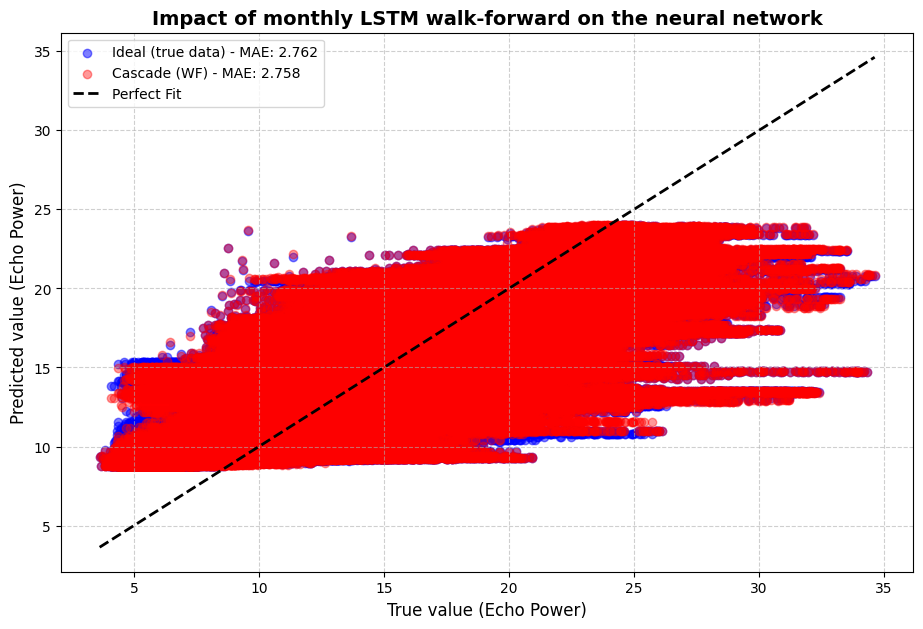

In [29]:
print("\n=== Extraction, NN Training, and Final Evaluation ===")
timestamp_plot_exp = datetime.now().strftime("%Y%m%d_%H%M%S")
orbit_file_path_cs = "../Data/orbit_to_remove" 

X_train_nn, y_train_nn, _ = load_and_preprocess_data(dataset_path=train_csv_path, orbit_path=orbit_file_path_cs, keep_flux=True)
X_test_ideal_nn, y_test_ideal_nn, _ = load_and_preprocess_data(dataset_path=ideal_csv_path, orbit_path=orbit_file_path_cs, keep_flux=True)
X_test_cascade_nn, y_test_cascade_nn, _ = load_and_preprocess_data(dataset_path=cascade_csv_path, orbit_path=orbit_file_path_cs, keep_flux=True)

# Standardization
scaler_nn_wf = StandardScaler()
X_train_nn_scaled = scaler_nn_wf.fit_transform(X_train_nn)
X_test_ideal_nn_scaled = scaler_nn_wf.transform(X_test_ideal_nn)
X_test_cascade_nn_scaled = scaler_nn_wf.transform(X_test_cascade_nn)

# Training of the main neural network (on actual historical data)
main_model_wf, device_nn, _ = train_pytorch_model(
    X_train=X_train_nn_scaled, y_train=y_train_nn, input_dim=X_train_nn_scaled.shape[1],
    model_class=NeurNet, epochs=1000, patience=10, batch_size=256
)

# Inference
main_model_wf.eval()
with torch.no_grad():
    X_ideal_tensor_wf = torch.tensor(X_test_ideal_nn_scaled, dtype=torch.float32).to(device_nn)
    X_cascade_tensor_wf = torch.tensor(X_test_cascade_nn_scaled, dtype=torch.float32).to(device_nn)
    
    y_pred_ideal_nn = main_model_wf(X_ideal_tensor_wf).cpu().numpy().flatten()
    y_pred_cascade_nn = main_model_wf(X_cascade_tensor_wf).cpu().numpy().flatten()

# Calculating metrics
mae_ideal_nn = mean_absolute_error(y_test_ideal_nn, y_pred_ideal_nn)
mae_cascade_nn = mean_absolute_error(y_test_cascade_nn, y_pred_cascade_nn)

os.makedirs("saved_main_model", exist_ok=True)
model_save_path_cs = f"saved_main_model/main_nn_model_WF_{timestamp_plot_exp}.pth"
scaler_save_path_cs = f"saved_main_model/main_nn_scaler_WF_{timestamp_plot_exp}.save"
torch.save(main_model_wf.state_dict(), model_save_path_cs)
dump(scaler_nn_wf, scaler_save_path_cs)

print(f"\nModel and Scaler saved successfully in:")
print(f"- {model_save_path_cs}")
print(f"- {scaler_save_path_cs}")

print("="*60)
print("FINAL REPORT: cascading walk-forward experiment (month-by-month)")
print("="*60)
print(f"SCENARIO 1: True Flux       -> MAE: {mae_ideal_nn:.4f}")
print(f"SCENARIO 2: Predicted Flux WF -> MAE: {mae_cascade_nn:.4f}")
print(f"Performance degradation:  +{((mae_cascade_nn - mae_ideal_nn) / mae_ideal_nn) * 100:.2f}%")
print("="*60)

# final plot
plt.figure(figsize=(11, 7))
plt.scatter(y_test_ideal_nn, y_pred_ideal_nn, alpha=0.5, color='blue', label=f'Ideal (true data) - MAE: {mae_ideal_nn:.3f}')
plt.scatter(y_test_cascade_nn, y_pred_cascade_nn, alpha=0.4, color='red', label=f'Cascade (WF) - MAE: {mae_cascade_nn:.3f}')
plt.plot([y_test_ideal_nn.min(), y_test_ideal_nn.max()], [y_test_ideal_nn.min(), y_test_ideal_nn.max()], 'k--', lw=2, label='Perfect Fit')

plt.title('Impact of monthly LSTM walk-forward on the neural network', fontsize=14, fontweight='bold')
plt.xlabel('True value (Echo Power)', fontsize=12)
plt.ylabel('Predicted value (Echo Power)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

os.makedirs("plots", exist_ok=True)
pdf_filename_cs = f"plots/WF_cascade_comparison_{timestamp_plot_exp}.pdf"
png_filename_cs = f"plots/WF_cascade_comparison_{timestamp_plot_exp}.png"
plt.savefig(pdf_filename_cs, format='pdf', bbox_inches='tight', dpi=600, facecolor='white')
plt.savefig(png_filename_cs, format='png', bbox_inches='tight', dpi=600, facecolor='white')
plt.show()